# Web Scraping

## Capturando o HTML da Vítima

In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
# URL da vítima
url = "https://www.eurogamer.pt/news?page=1"

# Cabeçalho para simular um navegador
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36"
}

In [ ]:
response = requests.get(url, headers=headers)
response
# <Response [200]> -> requisição foi bem-sucedida

<Response [200]>

In [ ]:
response.text

'<!DOCTYPE html>\n<html lang="pt">\n  <head>\n          <meta charset="utf-8">\n      <meta name="viewport" content="width=device-width, initial-scale=1.0, minimum-scale=1.0, maximum-scale=5.0">\n      <meta http-equiv="X-UA-Compatible" content="ie=edge">\n      <meta name="format-detection" content="telephone=no">\n\n      <title>Notícias | Eurogamer.pt</title>\n\n  <meta property="og:description" content="Eurogamer.pt">\n  <meta property="og:site_name" content="Eurogamer.pt">\n  <meta property="og:title" content="Notícias">\n  <meta property="og:type" content="website">\n  <meta property="og:url" content="https://www.eurogamer.pt/news">\n  <meta property="og:image" content="https://assetsio.gnwcdn.com/The-Cube%2C-Save-Us.jpg?width=1200&amp;height=630&amp;fit=crop&amp;enable=upscale&amp;auto=webp">\n\n  <meta name="description" content="Eurogamer.pt">\n  <meta name="twitter:card" content="summary_large_image">\n  <meta name="twitter:description" content="Eurogamer.pt">\n  <meta name="

In [ ]:
soup = BeautifulSoup(response.text, "html.parser")
soup

<!DOCTYPE html>

<html lang="pt">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1.0, minimum-scale=1.0, maximum-scale=5.0" name="viewport"/>
<meta content="ie=edge" http-equiv="X-UA-Compatible"/>
<meta content="telephone=no" name="format-detection"/>
<title>Notícias | Eurogamer.pt</title>
<meta content="Eurogamer.pt" property="og:description"/>
<meta content="Eurogamer.pt" property="og:site_name"/>
<meta content="Notícias" property="og:title"/>
<meta content="website" property="og:type"/>
<meta content="https://www.eurogamer.pt/news" property="og:url"/>
<meta content="https://assetsio.gnwcdn.com/The-Cube%2C-Save-Us.jpg?width=1200&amp;height=630&amp;fit=crop&amp;enable=upscale&amp;auto=webp" property="og:image"/>
<meta content="Eurogamer.pt" name="description"/>
<meta content="summary_large_image" name="twitter:card"/>
<meta content="Eurogamer.pt" name="twitter:description"/>
<meta content="Notícias" name="twitter:title"/>
<meta content="https://assetsi

In [ ]:
# Exibe o html como texto
print(soup.get_text())








Notícias | Eurogamer.pt































































Passar para o conteúdo principal




                      Análise Razer Viper V4 Pro Branco
                



                      Análise Mega Man Star Force Legacy Collection
                



                      Análise Super Mario Bros. Wonder Switch 2 Edition
                



                      Análise Marathon
                



                      Análise Monster Hunter Stories 3
                



                      Promoções
                








Eurogamer.pt 





Go






      Apoia-nos
    

Iniciar Sessão / Criar conta          








                      PC
                



                      PlayStation
                



                      Xbox
                



                      Nintendo
                



                      Notícias
                



                      Análises
                



                      Víde

In [ ]:
# Localizando todos os artigos da página de listagem
noticias = soup.find_all("article", class_="archive__item")
noticias

[<article class="archive__item" data-premium="false" data-sponsored="false">
 <div class="archive__thumbnail">
 <div class="thumbnail">
 <noscript>
 <img alt="Novo extraction shooter The Cube, Save Us só durou 52 dias" height="1080" src="https://assetsio.gnwcdn.com/The-Cube%2C-Save-Us.jpg?width=2048&amp;height=2048&amp;fit=bounds&amp;quality=85&amp;format=jpg&amp;auto=webp" style="aspect-ratio: 1.7777777777777777" width="1920"/>
 </noscript>
 <img alt="Novo extraction shooter The Cube, Save Us só durou 52 dias" data-autosize="crop_lossy" data-uri="The-Cube%2C-Save-Us.jpg" height="1080" loading="lazy" style="aspect-ratio: 1.7777777777777777" width="1920"/>
 </div> </div>
 <div class="archive__details">
 <div class="archive__type">
                 Notícias
               </div>
 <h2 class="archive__title">
 <a class="link link--expand link--invert" href="https://www.eurogamer.pt/novo-extraction-shooter-the-cube-save-us-so-durou-52-dias">
                   Novo extraction shooter The Cu

In [ ]:
# Inspecionando os campos de cada notícia na listagem
for noticia in noticias:
    titulo = noticia.find("h2", class_="archive__title").get_text(strip=True)
    link = noticia.find("a")["href"]
    resumo = noticia.find("div", class_="archive__strapline")
    resumo = resumo.get_text(strip=True) if resumo else None

    data = noticia.find("time").get_text(strip=True)
    autor = noticia.find("span", class_="archive__author").get_text(strip=True)

    print({
        "titulo": titulo,
        "link": link,
        "resumo": resumo,
        "data": data,
        "autor": autor
    })

{'titulo': 'Novo extraction shooter The Cube, Save Us só durou 52 dias', 'link': 'https://www.eurogamer.pt/novo-extraction-shooter-the-cube-save-us-so-durou-52-dias', 'resumo': 'A maldição dos live-service?', 'data': '10 de Abril de 2026', 'autor': 'Adolfo Soares'}
{'titulo': 'Valor Mortis é o novo soulslike na primeira pessoa e já temos gameplay', 'link': 'https://www.eurogamer.pt/valor-mortis-e-o-novo-soulslike-na-primeira-pessoa-e-ja-temos-gameplay', 'resumo': 'Trailer revela a data de lançamento.', 'data': '9 de Abril de 2026', 'autor': 'Adolfo Soares'}
{'titulo': 'Trailer Final de Mortal Kombat II: Johnny Cage, muito sangue e foco no verdadeiro torneio', 'link': 'https://www.eurogamer.pt/trailer-final-de-mortal-kombat-ii-johnny-cage-muito-sangue-e-foco-no-verdadeiro-torneio', 'resumo': 'Promete ser o filme mais sangrento do verão.', 'data': '9 de Abril de 2026', 'autor': 'Adolfo Soares'}
{'titulo': 'Filme de Metal Gear Solid é oficialmente confirmado pela Sony', 'link': 'https://w

In [ ]:
# Coletando os links da listagem
links = []

noticias = soup.find_all("article", class_="archive__item")

for noticia in noticias:
    a = noticia.find("a")
    if a and a.get("href"):
        links.append(a["href"])

# Garantindo que todos os links sejam URLs completas
base_url = "https://www.eurogamer.pt"
links = [
    link if link.startswith("https") else base_url + link
    for link in links
]

print(links)

['https://www.eurogamer.pt/novo-extraction-shooter-the-cube-save-us-so-durou-52-dias', 'https://www.eurogamer.pt/valor-mortis-e-o-novo-soulslike-na-primeira-pessoa-e-ja-temos-gameplay', 'https://www.eurogamer.pt/trailer-final-de-mortal-kombat-ii-johnny-cage-muito-sangue-e-foco-no-verdadeiro-torneio', 'https://www.eurogamer.pt/filme-de-metal-gear-solid-e-oficialmente-confirmado-pela-sony', 'https://www.eurogamer.pt/forbes-diz-que-marathon-custou-mais-de-250-milhoes-a-sony', 'https://www.eurogamer.pt/nova-atualizacao-de-pokemon-pokopia-resolve-erros-graves-na-switch-2', 'https://www.eurogamer.pt/novo-jogo-gratis-no-steam-conduz-e-repara-o-teu-proprio-camiao-nas-perigosas-estradas-da-america-do-sul', 'https://www.eurogamer.pt/a-dura-realidade-o-que-a-switch-2-precisa-de-sacrificar-para-correr-crimson-desert', 'https://www.eurogamer.pt/efootball-atinge-mil-milhoes-de-downloads', 'https://www.eurogamer.pt/crimson-desert-da-ps5-tenta-resistir-no-top-japones-dominado-pela-nintendo', 'https://

In [ ]:
# Acessando a primeira notícia para testar
full_url = links[0]
response = requests.get(full_url, headers=headers)
print(full_url)

https://www.eurogamer.pt/novo-extraction-shooter-the-cube-save-us-so-durou-52-dias


In [ ]:
soup_noticia = BeautifulSoup(response.text, "html.parser")
soup_noticia

<!DOCTYPE html>

<html lang="pt">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1.0, minimum-scale=1.0, maximum-scale=5.0" name="viewport"/>
<meta content="ie=edge" http-equiv="X-UA-Compatible"/>
<meta content="telephone=no" name="format-detection"/>
<title>Novo extraction shooter The Cube, Save Us só durou 52 dias | Eurogamer.pt</title>
<meta content="O MMO de extração The Cube, Save Us vai encerrar servidores a 8 de maio, totalizando 52 dias no Steam. A produtora confirmou reembolsos totais para as compras i" property="og:description"/>
<meta content="Eurogamer.pt" property="og:site_name"/>
<meta content="Novo extraction shooter The Cube, Save Us só durou 52 dias" property="og:title"/>
<meta content="article" property="og:type"/>
<meta content="https://www.eurogamer.pt/novo-extraction-shooter-the-cube-save-us-so-durou-52-dias" property="og:url"/>
<meta content="https://assetsio.gnwcdn.com/The-Cube%2C-Save-Us.jpg?width=1200&amp;height=630&amp;fit=crop

In [ ]:
print(soup_noticia.get_text(separator="\n").strip())

Novo extraction shooter The Cube, Save Us só durou 52 dias | Eurogamer.pt


























































































































































Passar para o conteúdo principal









                      Análise Razer Viper V4 Pro Branco
                







                      Análise Mega Man Star Force Legacy Collection
                







                      Análise Super Mario Bros. Wonder Switch 2 Edition
                







                      Análise Marathon
                







                      Análise Monster Hunter Stories 3
                







                      Promoções
                


















Eurogamer.pt
 












Go













      Apoia-nos
    



Iniciar Sessão / Criar conta          

















                      PC
                







                      PlayStation
                







                      X

In [ ]:
# Extraindo metadados da notícia via tags <meta>

# Título
title = soup_noticia.find("meta", property="og:title")["content"]

# Descrição
description = soup_noticia.find("meta", property="og:description")["content"]

# Data de publicação
date = soup_noticia.find("meta", property="article:published_time")["content"]

# Autor (vem na tag <span class="author__name"> ou <meta name="author">)
author_tag = soup_noticia.find("meta", attrs={"name": "author"})
author = author_tag["content"] if author_tag else None

# Tags / categorias do artigo
tags = [tag["content"] for tag in soup_noticia.find_all("meta", property="article:tag")]

print("Título:", title)
print("Descrição:", description)
print("Data:", date)
print("Autor:", author)
print("Tags:", tags)

Título: Novo extraction shooter The Cube, Save Us só durou 52 dias
Descrição: O MMO de extração The Cube, Save Us vai encerrar servidores a 8 de maio, totalizando 52 dias no Steam. A produtora confirmou reembolsos totais para as compras i
Data: 2026-04-10T00:17:27.066454+00:00
Autor: None
Tags: ['PC']


In [ ]:
# Extraindo o corpo do texto da notícia
corpo_noticia = soup_noticia.find("div", class_="article_body_content")

# Limpando e extraindo só o texto
texto = corpo_noticia.get_text(separator="\n").strip()

In [ ]:
print(texto)

A era dos jogos live-service continua a revelar-se difícil para os novos projectos. O jogo The Cube, Save Us, um MMO de extração de ficção científica, vai encerrar os seus servidores menos de dois meses após o seu lançamento.


A produtora XLGames anunciou que o jogo será encerrado definitivamente a 8 de maio (ou 7 de maio, dependendo do fuso horário). Dado que o jogo foi lançado no Steam a 17 de março, só vai estar 52 dias no mercado. O servidor Discord oficial do jogo será encerrado na mesma data.


Da popularidade na demo a uma queda vertiginosa


O jogo tem por base uma narrativa em que, depois de uma nova Guerra Fria, um enorme cubo apareceu e destruiu o mundo. Décadas mais tarde, os sobreviventes atravessam os “Cube Gates”, explorando 27 arenas dinâmicas, como centros de cidades, pirâmides ou parques de diversões. A jogabilidade é caracterizada por ser uma experiência PvPvE focada no combate corpo a corpo, em vez das tradicionais mecânicas de tiro.



A demo foi um dos jogos mais

In [ ]:
# Montando o dicionário com todas as informações da notícia
informacoes = {
    "url": full_url,
    "titulo": title,
    "descricao": description,
    "autor": author,
    "tags": tags,
    "texto": texto,
    "data": date,
}

In [ ]:
informacoes

{'url': 'https://www.eurogamer.pt/novo-extraction-shooter-the-cube-save-us-so-durou-52-dias',
 'titulo': 'Novo extraction shooter The Cube, Save Us só durou 52 dias',
 'descricao': 'O MMO de extração The Cube, Save Us vai encerrar servidores a 8 de maio, totalizando 52 dias no Steam. A produtora confirmou reembolsos totais para as compras i',
 'autor': None,
 'tags': ['PC'],
 'texto': 'A era dos jogos live-service continua a revelar-se difícil para os novos projectos. O jogo The Cube, Save Us, um MMO de extração de ficção científica, vai encerrar os seus servidores menos de dois meses após o seu lançamento.\n\n\nA produtora XLGames anunciou que o jogo será encerrado definitivamente a 8 de maio (ou 7 de maio, dependendo do fuso horário). Dado que o jogo foi lançado no Steam a 17 de março, só vai estar 52 dias no mercado. O servidor Discord oficial do jogo será encerrado na mesma data.\n\n\nDa popularidade na demo a uma queda vertiginosa\n\n\nO jogo tem por base uma narrativa em que, dep

In [ ]:
import time
import random

In [ ]:
numero_paginas = 70
# numero_paginas = 5

links_noticias = []

for p in range(1, numero_paginas + 1):
    url = f"https://www.eurogamer.pt/news?page={p}"
    response = requests.get(url, headers=headers)

    print(p, response)

    soup = BeautifulSoup(response.text, "html.parser")
    noticias = soup.find_all("article", class_="archive__item")

    for noticia in noticias:
        a = noticia.find("a")
        if a and a.get("href"):
            link = a["href"]
            # Garante URL completa
            if not link.startswith("https"):
                link = "https://www.eurogamer.pt" + link
            links_noticias.append(link)

    # Esperar alguns segundos antes de ir para a próxima página
    tempo_espera = random.uniform(0.5, 1.5)
    time.sleep(tempo_espera)

1 <Response [200]>
2 <Response [200]>
3 <Response [200]>
4 <Response [200]>
5 <Response [200]>
6 <Response [200]>
7 <Response [200]>
8 <Response [200]>
9 <Response [200]>
10 <Response [200]>
11 <Response [200]>
12 <Response [200]>
13 <Response [200]>
14 <Response [200]>
15 <Response [200]>
16 <Response [200]>
17 <Response [200]>
18 <Response [200]>
19 <Response [200]>
20 <Response [200]>
21 <Response [200]>
22 <Response [200]>
23 <Response [200]>
24 <Response [200]>
25 <Response [200]>
26 <Response [200]>
27 <Response [200]>
28 <Response [200]>
29 <Response [200]>
30 <Response [200]>
31 <Response [200]>
32 <Response [200]>
33 <Response [200]>
34 <Response [200]>
35 <Response [200]>
36 <Response [200]>
37 <Response [200]>
38 <Response [200]>
39 <Response [200]>
40 <Response [200]>
41 <Response [200]>
42 <Response [200]>
43 <Response [200]>
44 <Response [200]>
45 <Response [200]>
46 <Response [200]>
47 <Response [200]>
48 <Response [200]>
49 <Response [200]>
50 <Response [200]>
51 <Respo

In [ ]:
len(links_noticias)

1750

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
import json
import pathlib

data_dir = pathlib.Path("data")  # Diretório onde os arquivos serão salvos
data_dir.mkdir(exist_ok=True)

for i, full_url in enumerate(links_noticias):
    response = requests.get(full_url, headers=headers)

    soup_noticia = BeautifulSoup(response.text, "html.parser")

    try:
        title = soup_noticia.find("meta", property="og:title")["content"]
        description = soup_noticia.find("meta", property="og:description")["content"]
        date = soup_noticia.find("meta", property="article:published_time")["content"]
        author_tag = soup_noticia.find("meta", attrs={"name": "author"})
        author = author_tag["content"] if author_tag else None
        tags = [tag["content"] for tag in soup_noticia.find_all("meta", property="article:tag")]

        corpo_noticia = soup_noticia.find("div", class_="article_body_content")
        texto = corpo_noticia.get_text(separator="\n").strip() if corpo_noticia else ""
    except Exception as e:
        print(f"Erro ao processar {full_url}: {e}")
        continue

    informacoes = {
        "url": full_url,
        "titulo": title,
        "descricao": description,
        "autor": author,
        "tags": tags,
        "texto": texto,
        "data": date,
    }

    filename = f"noticia_{i}.json"
    file_path = data_dir / filename

    with file_path.open("w", encoding="utf-8") as f:
        json.dump(informacoes, f, ensure_ascii=False, indent=4)

    print(f"Arquivo salvo: {file_path}")

    tempo_espera = random.uniform(0.3, 1.0)
    time.sleep(tempo_espera)

Arquivo salvo: data/noticia_0.json
Arquivo salvo: data/noticia_1.json
Arquivo salvo: data/noticia_2.json
Arquivo salvo: data/noticia_3.json
Arquivo salvo: data/noticia_4.json
Arquivo salvo: data/noticia_5.json
Arquivo salvo: data/noticia_6.json
Arquivo salvo: data/noticia_7.json
Arquivo salvo: data/noticia_8.json
Arquivo salvo: data/noticia_9.json
Arquivo salvo: data/noticia_10.json
Arquivo salvo: data/noticia_11.json
Arquivo salvo: data/noticia_12.json
Arquivo salvo: data/noticia_13.json
Arquivo salvo: data/noticia_14.json
Arquivo salvo: data/noticia_15.json
Arquivo salvo: data/noticia_16.json
Arquivo salvo: data/noticia_17.json
Arquivo salvo: data/noticia_18.json
Arquivo salvo: data/noticia_19.json
Arquivo salvo: data/noticia_20.json
Arquivo salvo: data/noticia_21.json
Arquivo salvo: data/noticia_22.json
Arquivo salvo: data/noticia_23.json
Arquivo salvo: data/noticia_24.json
Arquivo salvo: data/noticia_25.json
Arquivo salvo: data/noticia_26.json
Arquivo salvo: data/noticia_27.json
Ar

In [ ]:
from joblib import Parallel, delayed

def processar_link(i, full_url):
    response = requests.get(full_url, headers=headers)
    soup_noticia = BeautifulSoup(response.text, "html.parser")

    try:
        title = soup_noticia.find("meta", property="og:title")["content"]
        description = soup_noticia.find("meta", property="og:description")["content"]
        date = soup_noticia.find("meta", property="article:published_time")["content"]
        author_tag = soup_noticia.find("meta", attrs={"name": "author"})
        author = author_tag["content"] if author_tag else None
        tags = [tag["content"] for tag in soup_noticia.find_all("meta", property="article:tag")]

        corpo_noticia = soup_noticia.find("div", class_="article_body_content")
        texto = corpo_noticia.get_text(separator="\n").strip() if corpo_noticia else ""
    except Exception as e:
        print(f"Erro ao processar {full_url}: {e}")
        return

    informacoes = {
        "url": full_url,
        "titulo": title,
        "descricao": description,
        "autor": author,
        "tags": tags,
        "texto": texto,
        "data": date,
    }

    file_path = data_dir / f"noticia_{i}.json"
    with file_path.open("w", encoding="utf-8") as f:
        json.dump(informacoes, f, ensure_ascii=False, indent=4)

    print(f"Arquivo salvo: {file_path}")

    tempo_espera = random.uniform(0, 0.5)
    time.sleep(tempo_espera)  # ainda vale a pena para não sobrecarregar o servidor


# Executa em paralelo com threads
Parallel(n_jobs=8, prefer="threads")(
    delayed(processar_link)(i, link) for i, link in enumerate(links_noticias)
)

Arquivo salvo: data/noticia_0.json
Arquivo salvo: data/noticia_5.json
Arquivo salvo: data/noticia_2.json
Arquivo salvo: data/noticia_1.json
Arquivo salvo: data/noticia_4.json
Arquivo salvo: data/noticia_6.json
Arquivo salvo: data/noticia_7.json
Arquivo salvo: data/noticia_3.json
Arquivo salvo: data/noticia_8.json
Arquivo salvo: data/noticia_9.json
Arquivo salvo: data/noticia_10.json
Arquivo salvo: data/noticia_11.json
Arquivo salvo: data/noticia_13.json
Arquivo salvo: data/noticia_12.json
Arquivo salvo: data/noticia_15.json
Arquivo salvo: data/noticia_16.json
Arquivo salvo: data/noticia_14.json
Arquivo salvo: data/noticia_17.json
Arquivo salvo: data/noticia_18.json
Arquivo salvo: data/noticia_19.json
Arquivo salvo: data/noticia_20.json
Arquivo salvo: data/noticia_22.json
Arquivo salvo: data/noticia_21.json
Arquivo salvo: data/noticia_23.json
Arquivo salvo: data/noticia_24.json
Arquivo salvo: data/noticia_25.json
Arquivo salvo: data/noticia_26.json
Arquivo salvo: data/noticia_30.json
Ar

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [ ]:
import matplotlib.pyplot as plt

# Caminho da pasta com os arquivos JSON
data_dir = pathlib.Path("data")

# Contador para as tags
tag_counter = {}

# Abrindo e processando os arquivos JSON
for json_file in data_dir.rglob("*.json"):
    with json_file.open("r", encoding="utf-8") as f:
        data = json.load(f)
        tags = data.get("tags", [])  # Obtém a lista de tags
        for tag in tags:
            if tag in tag_counter:
                tag_counter[tag] += 1
            else:
                tag_counter[tag] = 1

In [ ]:
import json
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from collections import Counter
import re

data_dir = pathlib.Path("data")

records = []
for json_file in data_dir.rglob("*.json"):
    with json_file.open("r", encoding="utf-8") as f:
        data = json.load(f)
        records.append(data)

df = pd.DataFrame(records)
df["data"] = pd.to_datetime(df["data"], utc=True, errors="coerce")
df["mes"] = df["data"].dt.to_period("M")
df["ano"] = df["data"].dt.year
df["dia_semana"] = df["data"].dt.day_name()
df["hora"] = df["data"].dt.hour
df["num_palavras"] = df["texto"].fillna("").apply(lambda x: len(x.split()))
df["num_chars"] = df["texto"].fillna("").apply(len)

print(f"Total de notícias carregadas: {len(df)}")
df.head()

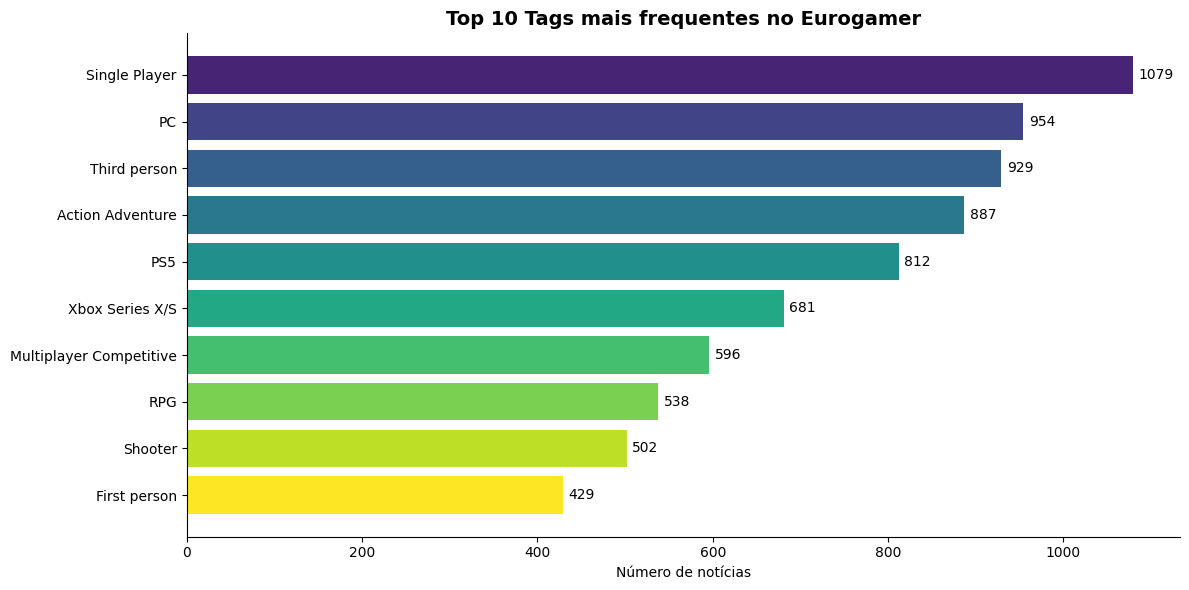

In [29]:
tag_counter = Counter(tag for tags in df["tags"].dropna() for tag in tags)
top_tags = tag_counter.most_common(10)
labels, values = zip(*top_tags)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(labels[::-1], values[::-1], color=plt.cm.viridis_r([i/10 for i in range(10)]))
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel("Número de notícias")
ax.set_title("Top 10 Tags mais frequentes no Eurogamer", fontsize=14, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

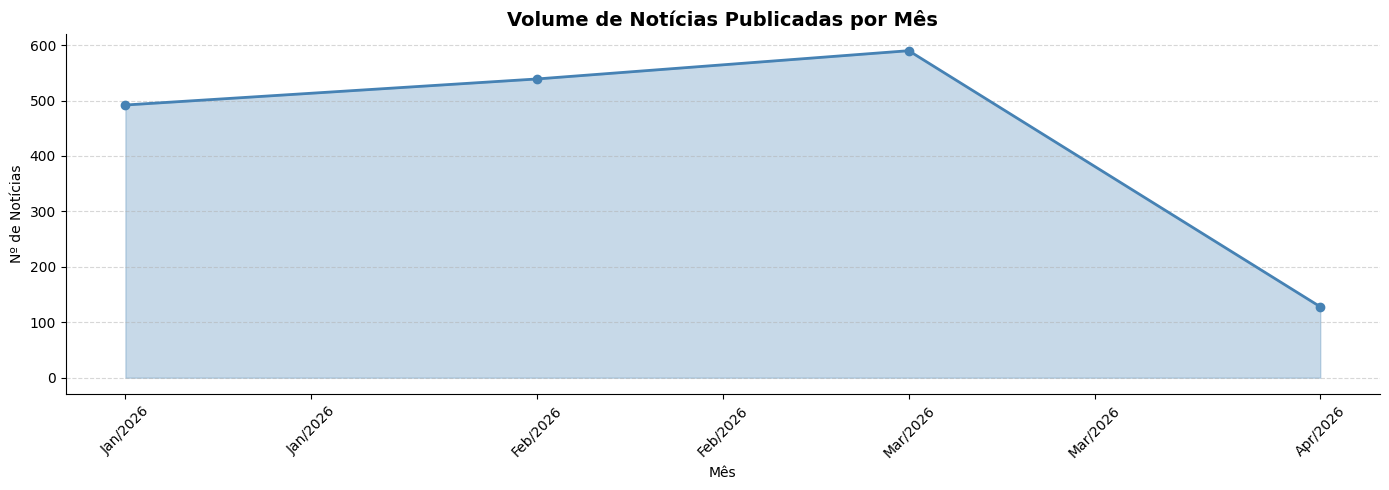

In [30]:
monthly = df.groupby("mes").size().reset_index(name="count")
monthly["mes_dt"] = monthly["mes"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly["mes_dt"], monthly["count"], alpha=0.3, color="steelblue")
ax.plot(monthly["mes_dt"], monthly["count"], marker="o", color="steelblue", linewidth=2)
ax.set_title("Volume de Notícias Publicadas por Mês", fontsize=14, fontweight="bold")
ax.set_xlabel("Mês")
ax.set_ylabel("Nº de Notícias")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=45)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

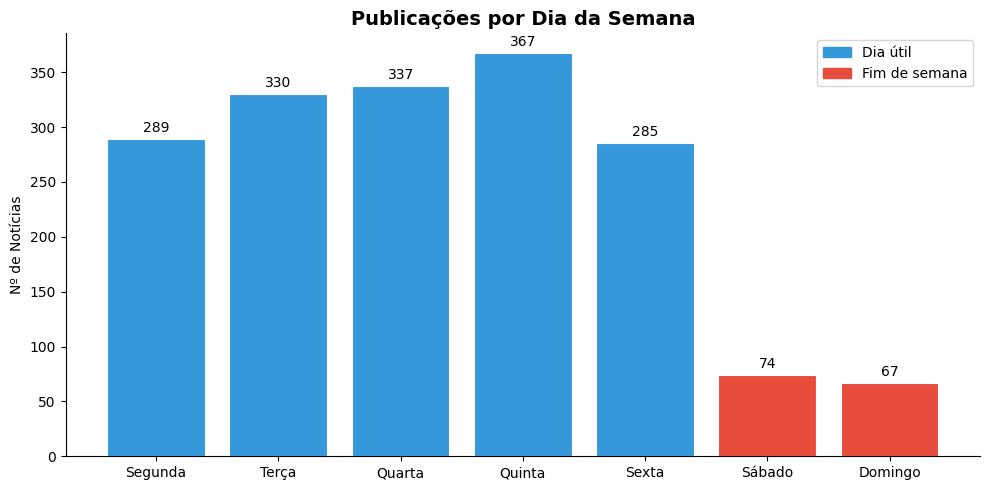

In [31]:
ordem_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
nomes_pt = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]

day_counts = df["dia_semana"].value_counts().reindex(ordem_dias).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
cores = ["#e74c3c" if d in ["Saturday", "Sunday"] else "#3498db" for d in ordem_dias]
bars = ax.bar(nomes_pt, day_counts.values, color=cores, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title("Publicações por Dia da Semana", fontsize=14, fontweight="bold")
ax.set_ylabel("Nº de Notícias")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color="#3498db", label="Dia útil"),
    plt.Rectangle((0,0),1,1, color="#e74c3c", label="Fim de semana")
], loc="upper right")
plt.tight_layout()
plt.show()

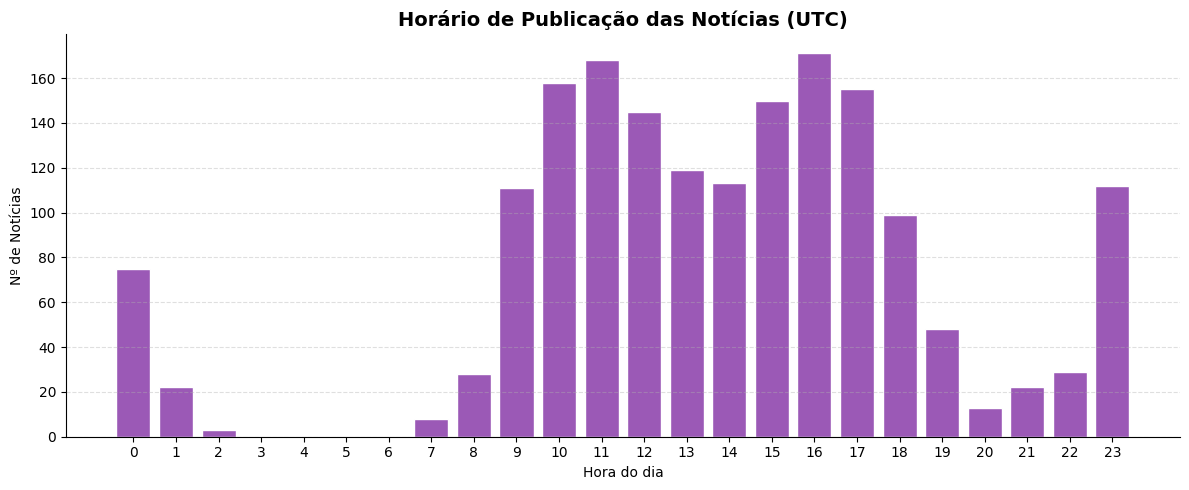

In [32]:
hora_counts = df["hora"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hora_counts.index, hora_counts.values, color="#9b59b6", edgecolor="white")
ax.set_title("Horário de Publicação das Notícias (UTC)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Nº de Notícias")
ax.set_xticks(range(0, 24))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7818/933161735.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_box, labels=[str(int(a)) for a in anos], patch_artist=True,


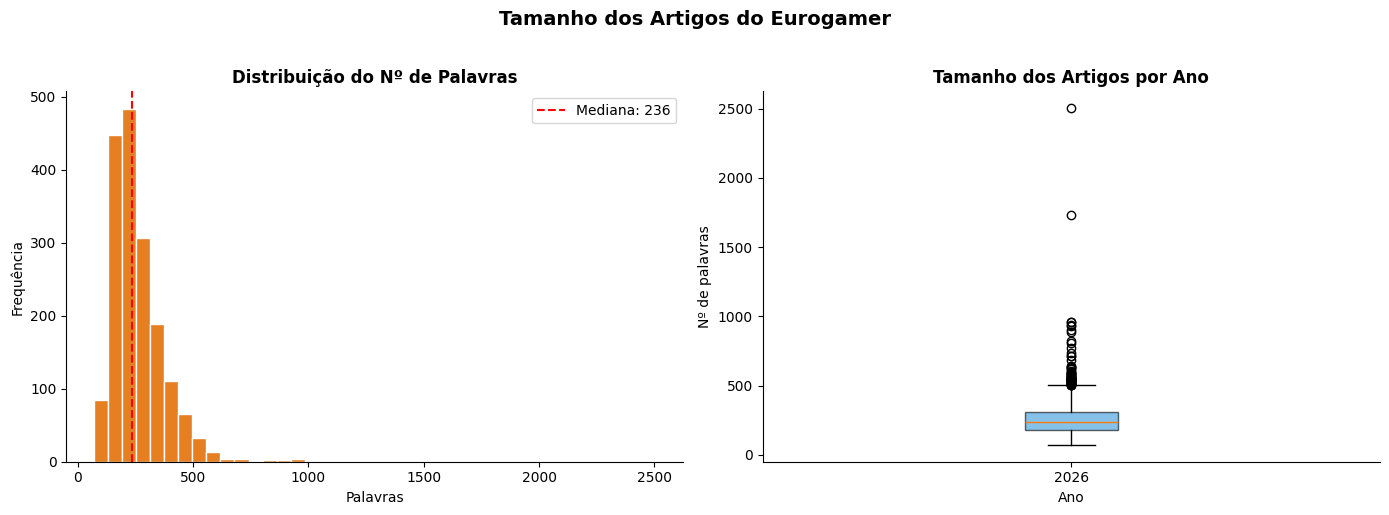

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de palavras
axes[0].hist(df["num_palavras"].dropna(), bins=40, color="#e67e22", edgecolor="white")
axes[0].set_title("Distribuição do Nº de Palavras", fontweight="bold")
axes[0].set_xlabel("Palavras")
axes[0].set_ylabel("Frequência")
axes[0].axvline(df["num_palavras"].median(), color="red", linestyle="--",
                label=f'Mediana: {df["num_palavras"].median():.0f}')
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

# Boxplot por ano
anos = sorted(df["ano"].dropna().unique())
data_box = [df[df["ano"] == a]["num_palavras"].dropna().values for a in anos]
axes[1].boxplot(data_box, labels=[str(int(a)) for a in anos], patch_artist=True,
                boxprops=dict(facecolor="#3498db", alpha=0.6))
axes[1].set_title("Tamanho dos Artigos por Ano", fontweight="bold")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Nº de palavras")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Tamanho dos Artigos do Eurogamer", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

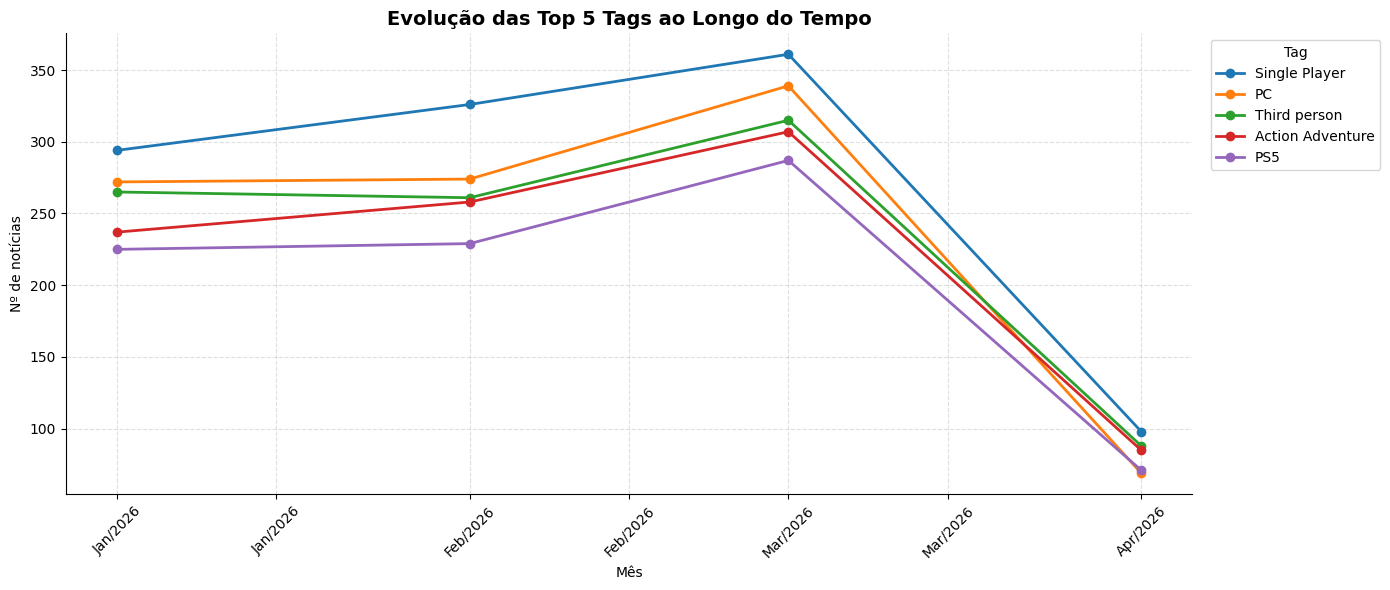

In [35]:
# Explodindo as tags para uma linha por tag
df_tags = df[["mes", "tags"]].explode("tags").dropna(subset=["tags"])
df_tags["mes_dt"] = df_tags["mes"].dt.to_timestamp()

top5 = [t for t, _ in tag_counter.most_common(5)]

fig, ax = plt.subplots(figsize=(14, 6))
for tag in top5:
    serie = (
        df_tags[df_tags["tags"] == tag]
        .groupby("mes_dt")
        .size()
        .reset_index(name="count")
    )
    ax.plot(serie["mes_dt"], serie["count"], marker="o", linewidth=2, label=tag)

ax.set_title("Evolução das Top 5 Tags ao Longo do Tempo", fontsize=14, fontweight="bold")
ax.set_xlabel("Mês")
ax.set_ylabel("Nº de notícias")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=45)
ax.legend(title="Tag", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

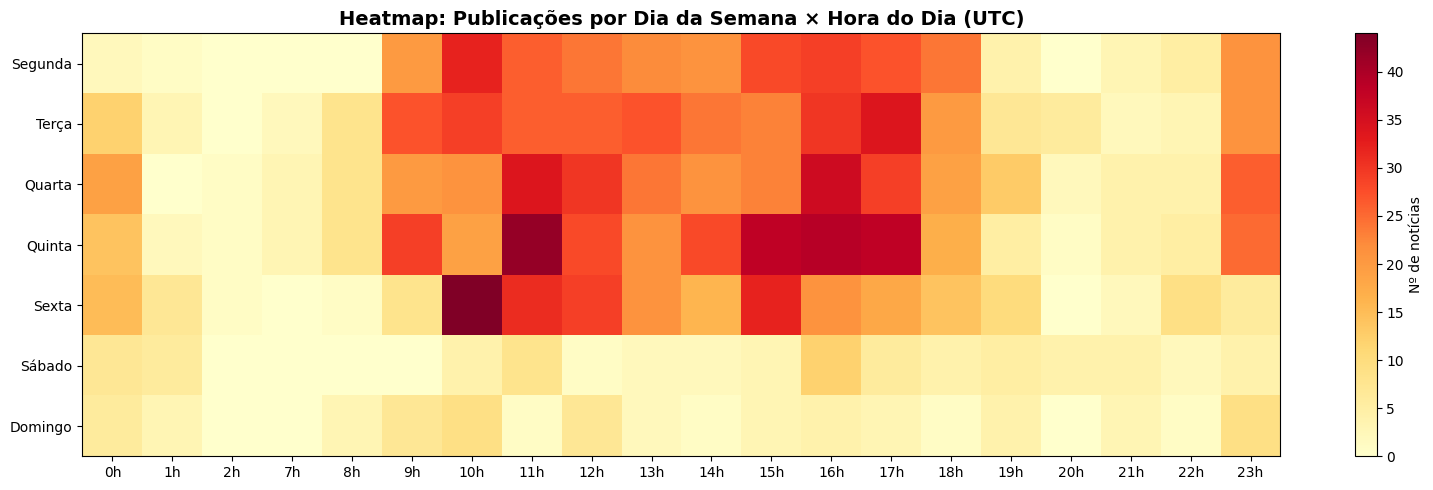

In [36]:
import numpy as np

pivot = (
    df.groupby(["dia_semana", "hora"])
    .size()
    .reset_index(name="count")
    .pivot(index="dia_semana", columns="hora", values="count")
    .reindex(ordem_dias)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="Nº de notícias")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{h}h" for h in pivot.columns])
ax.set_yticks(range(len(ordem_dias)))
ax.set_yticklabels(nomes_pt)
ax.set_title("Heatmap: Publicações por Dia da Semana × Hora do Dia (UTC)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

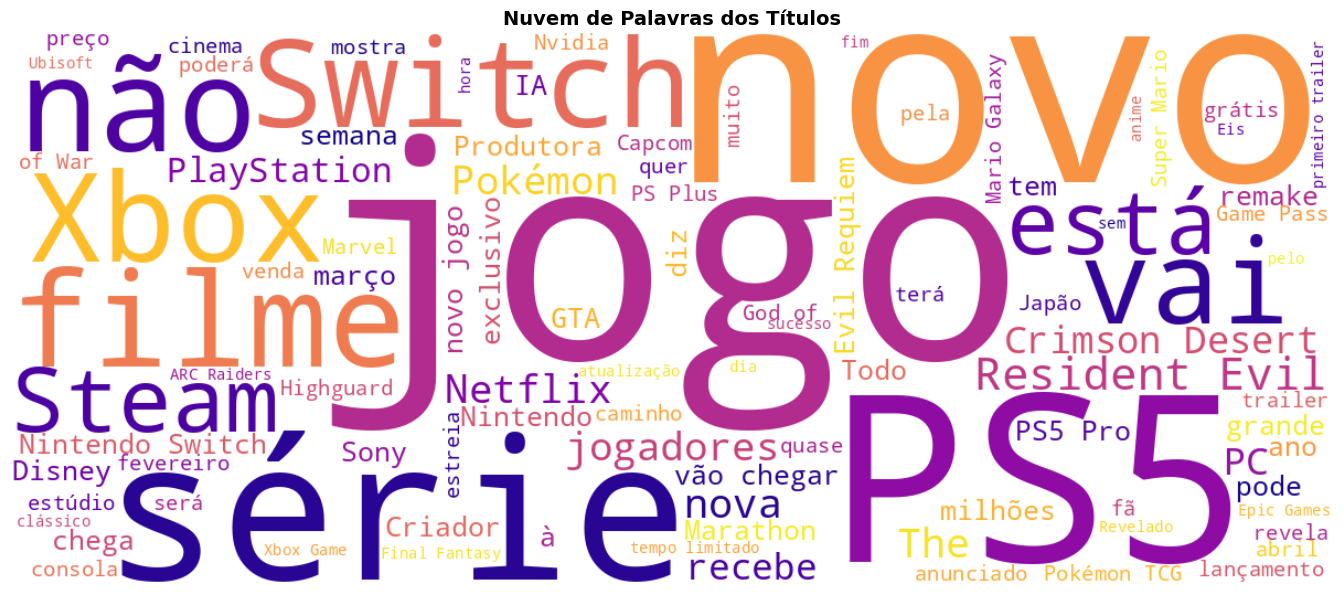

In [37]:
from wordcloud import WordCloud

stopwords_pt = {
    "de", "da", "do", "dos", "das", "e", "em", "o", "a", "os", "as",
    "para", "com", "um", "uma", "no", "na", "nos", "nas", "que", "é",
    "se", "por", "ao", "aos", "mais", "já", "ser", "foi", "como",
    "mas", "ou", "sua", "seu", "seus", "suas", "este", "esta", "sobre"
}

todos_titulos = " ".join(df["titulo"].dropna())

wc = WordCloud(
    width=1200, height=500,
    background_color="white",
    stopwords=stopwords_pt,
    colormap="plasma",
    max_words=100
).generate(todos_titulos)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nuvem de Palavras dos Títulos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

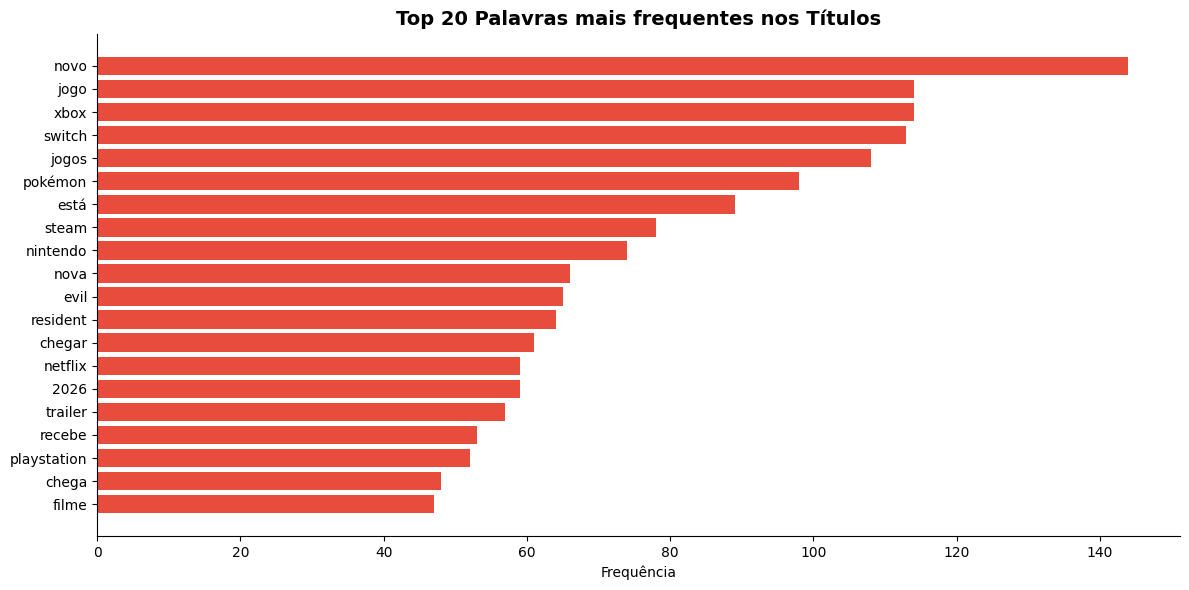

In [38]:
from collections import Counter
import re

palavras = re.findall(r'\b\w{4,}\b', todos_titulos.lower())
palavras_filtradas = [p for p in palavras if p not in stopwords_pt]
top_palavras = Counter(palavras_filtradas).most_common(20)

words, freqs = zip(*top_palavras)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(words[::-1], freqs[::-1], color="#e74c3c")
ax.set_title("Top 20 Palavras mais frequentes nos Títulos", fontsize=14, fontweight="bold")
ax.set_xlabel("Frequência")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

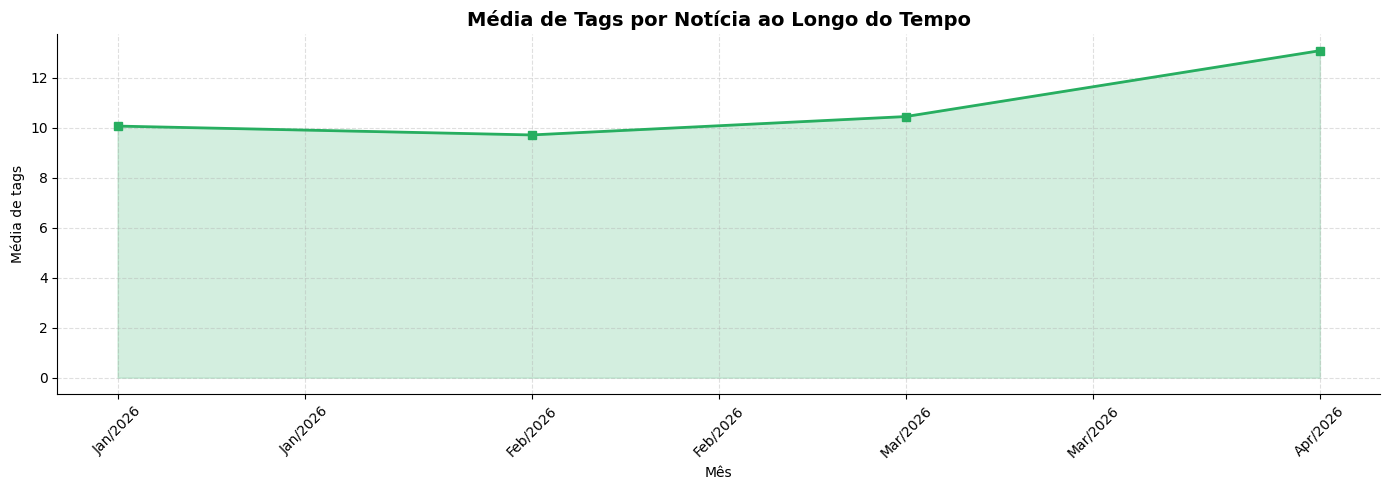

In [39]:
df["num_tags"] = df["tags"].apply(lambda x: len(x) if isinstance(x, list) else 0)

tags_mes = df.groupby("mes")["num_tags"].mean().reset_index()
tags_mes["mes_dt"] = tags_mes["mes"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tags_mes["mes_dt"], tags_mes["num_tags"], marker="s",
        color="#27ae60", linewidth=2)
ax.fill_between(tags_mes["mes_dt"], tags_mes["num_tags"], alpha=0.2, color="#27ae60")
ax.set_title("Média de Tags por Notícia ao Longo do Tempo", fontsize=14, fontweight="bold")
ax.set_xlabel("Mês")
ax.set_ylabel("Média de tags")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=45)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

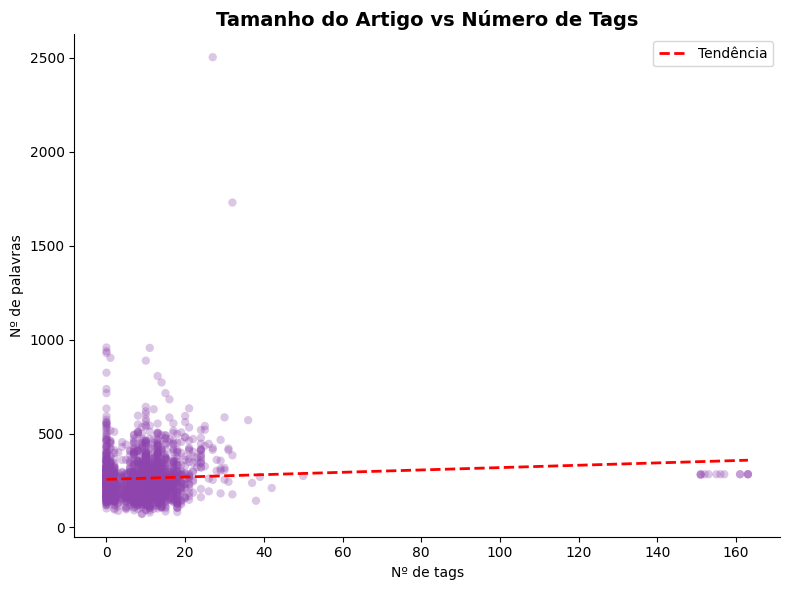

Correlação de Pearson: 0.069


In [40]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["num_tags"], df["num_palavras"], alpha=0.3, color="#8e44ad", edgecolors="none")

# Linha de tendência
mask = df["num_tags"].notna() & df["num_palavras"].notna()
z = np.polyfit(df.loc[mask, "num_tags"], df.loc[mask, "num_palavras"], 1)
p = np.poly1d(z)
xs = np.linspace(df["num_tags"].min(), df["num_tags"].max(), 100)
ax.plot(xs, p(xs), color="red", linewidth=2, linestyle="--", label="Tendência")

ax.set_title("Tamanho do Artigo vs Número de Tags", fontsize=14, fontweight="bold")
ax.set_xlabel("Nº de tags")
ax.set_ylabel("Nº de palavras")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

corr = df[["num_tags", "num_palavras"]].corr().iloc[0, 1]
print(f"Correlação de Pearson: {corr:.3f}")

In [43]:
print("=" * 50)
print("       RESUMO DO SCRAPING - EUROGAMER PT")
print("=" * 50)
print(f"  Total de artigos coletados : {len(df)}")
print(f"  Período coberto            : {df['data'].min().date()} → {df['data'].max().date()}")
print(f"  Autores únicos             : {df['autor'].nunique()}")
print(f"  Tags únicas                : {len(tag_counter)}")
print(f"  Média de palavras/artigo   : {df['num_palavras'].mean():.0f}")
print(f"  Artigo mais longo          : {df['num_palavras'].max()} palavras")
print(f"  Tag mais comum             : {tag_counter.most_common(1)[0][0]} ({tag_counter.most_common(1)[0][1]}x)")
print("=" * 50)

       RESUMO DO SCRAPING - EUROGAMER PT
  Total de artigos coletados : 1749
  Período coberto            : 2026-01-02 → 2026-04-10
  Autores únicos             : 0
  Tags únicas                : 930
  Média de palavras/artigo   : 262
  Artigo mais longo          : 2504 palavras
  Tag mais comum             : Single Player (1079x)
